In [77]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import linalg as la

# from jax.numpy import einsum

# for coloring lines
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import blochK
import blochK.observable as observable
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import extent
from blochK.plotting.publication import (
    paper_style,
    paper_style_small,
    revtex_textwidth,
    revtex_columnwidth,
    set_size,
)
from blochK.observable import conductivity_orbital_resolved


import plot_funcs as pf

import sys, os


from alter_surf.utils3D import projector2layer

import pickle

matplotlib.rcParams.update(
    {
        "font.size": 7,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.9
aps_halfwidth = 3.4

In [79]:
sigma = [
    np.eye(2),
    np.array([[0, 1], [1, 0]]),
    np.array([[0, -1j], [1j, 0]]),
    np.array([[1, 0], [0, -1]]),
]


# order is spin, layer, sublattice

sym = np.kron(np.kron(sigma[2], sigma[0]), sigma[1])


def V(
    pm,
    on_site,
    spin_preserving=False,
    symmetry_preserving=True,
    rng=np.random.default_rng(),
):
    m1 = 1 - 2 * rng.random([8, 8])
    m2 = 1 - 2 * rng.random([8, 8])

    if symmetry_preserving:
        # make it symmetric
        m_plus = m1 + sym @ m1 @ sym
        m_minus = m1 - sym @ m1 @ sym

        matrix = m_plus + 1j * m_minus
        if pm == -1:
            matrix = (-1j * matrix).conj()
    else:
        matrix = m1 + 1j * m2

    if spin_preserving:  # only allowed s0 and sz in the perturbation
        matrix = matrix * np.kron(np.kron(sigma[0], np.ones((2, 2))), np.ones((2, 2)))

    if on_site:
        matrix = matrix * np.kron(np.kron(np.ones((2, 2)), np.ones((2, 2))), sigma[0])
    else:
        matrix = matrix * np.kron(np.kron(np.ones((2, 2)), np.ones((2, 2))), sigma[1])

    # make it hermitian
    return (matrix + matrix.T.conj()) / 2

In [80]:
def random_surface_perturbation(
    rng=np.random.default_rng(),
    spin_preserving=False,
    symmetry_preserving=True,
    run_checks=False,
):
    # generate the random matrices that will be used in the perturbation
    vparams = {
        "spin_preserving": spin_preserving,
        "symmetry_preserving": symmetry_preserving,
        "rng": rng,
    }
    v_matrices = [
        V(1, True, **vparams),
        V(1, False, **vparams),
        V(1, False, **vparams),
        V(-1, False, **vparams),
        V(-1, False, **vparams),
    ]

    def func(kx, ky, strength_onsite=1, strength_nn=1, len_z=2, **kwargs):

        sk_p = np.sin((kx + ky) / 2) + np.sin((kx - ky) / 2)
        ck_p = np.cos((kx + ky) / 2) + np.cos((kx - ky) / 2)
        sk_m = np.sin((kx + ky) / 2) - np.sin((kx - ky) / 2)
        ck_m = np.cos((kx + ky) / 2) - np.cos((kx - ky) / 2)

        ones = np.ones_like(kx)
        v0 = strength_onsite * np.einsum("ij,k...->ijk...", v_matrices[0], ones)
        v1 = strength_nn * np.einsum("ij,k...->ijk...", v_matrices[1], sk_p)
        v2 = strength_nn * np.einsum("ij,k...->ijk...", v_matrices[2], ck_p)
        v3 = strength_nn * np.einsum("ij,k...->ijk...", v_matrices[3], sk_m)
        v4 = strength_nn * np.einsum("ij,k...->ijk...", v_matrices[4], ck_m)

        h = v0 + v1 + v2 + v3 + v4

        assert len_z > 1, "len_z must be greater than 1 "
        h_padded = np.zeros((len_z * 4, len_z * 4, *kx.shape), dtype=complex)
        h_padded[:8, :8] = h

        return h_padded

    if run_checks:
        random_k = rng.uniform(0, 2 * np.pi, size=[2, 3])
        h1 = func(random_k[0], random_k[1])
        h2 = func(random_k[0], -random_k[1])
        h1_pi = func(random_k[0], random_k[1] + 2 * np.pi)

        # check its periodic in k
        gauge = np.kron(np.kron(sigma[0], sigma[0]), sigma[3])
        assert np.allclose(h1, np.einsum("ij, jk..., kl -> il...", gauge, h1_pi, gauge))

        # check the symmetry
        h2_transformed = np.einsum("ij..., jk..., kl... -> il...", sym, h2.conj(), sym)
        # assert np.all(func(random_k[0], random_k[1]) == func(random_k[0], random_k[1]+2*np.pi))
        assert np.all(h2_transformed == h1), "Symmetry check failed"
        assert np.all(
            h1 == np.einsum("ij... -> ji...", h1.conj())
        ), "Hermiticity check failed"

    return func


# h = random_surface_perturbation(rng)
# KX, KY = np.meshgrid(np.linspace(0, 2 * np.pi, 10), np.linspace(0, 2 * np.pi, 10))
# H_k = h(KX, KY, len_z=8)

# from alter_surf.hamiltonian_CuMnAs import H_slab_fct

define the two models


In [81]:
# Drumhead Model
drumhead_params = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1)
Drumhead_2D = pf.slab_ham({"len_z": 31} | drumhead_params)


# Weyl Model
weyl_params = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1, dtpp=0.2)
Weyl_2D = pf.slab_ham({"len_z": 31} | weyl_params)

# make three perturbations with different random seeds
rng = np.random.default_rng(seed=19837)
perturbation_params = [
    {"symmetry_preserving": False, "spin_preserving": False, "rng": rng},
    {"symmetry_preserving": True, "spin_preserving": False, "rng": rng},
    {"symmetry_preserving": True, "spin_preserving": True, "rng": rng},
]

perturbations = [
    blochK.Hamiltonian2D(
        random_surface_perturbation(**params),
        param={"len_z": 31, "strength_onsite": 0.3, "strength_nn": 0.25},
    )
    for params in perturbation_params
]


base_models_2D = [Drumhead_2D, Weyl_2D]
base_model_names = ["Drumhead", "Weyl"]


six_models = np.array([[b + a for a in base_models_2D] for b in perturbations])

define the k space paths for everything


In [82]:
# define spectral paths
n_k_2d_path = 100
# n_k_2d_path = 20
# define 2d slice k grids
n_k_grid = 101
# n_k_grid = 21

# make slices
drum_weyl_points = np.array([[0, 1], [0, 0], [1, 0], [0, 1], [1, 1], [0, 0]])
drum_weyl_labels = [r"Y", r"$\Gamma$", r"X", r"Y", r"M", r"$\Gamma$"]
drum_weyl_path = pf.make_path(drum_weyl_points, n_k_2d_path)
drum_weyl_path_positions = np.linspace(
    0, len(drum_weyl_path), len(drum_weyl_labels)
).astype(int)

paths = [drum_weyl_path, drum_weyl_path]
path_labels = [drum_weyl_labels, drum_weyl_labels]
path_positions = [
    drum_weyl_path_positions,
    drum_weyl_path_positions,
]

# make grids
spillover = 0.25
k_slice = np.linspace(
    -np.pi * (1 + spillover), np.pi * (1 + spillover), n_k_grid, endpoint=False
)
KX_slice, KY_slice = np.meshgrid(k_slice, k_slice)

In [83]:
# solve paths
def solve_path(model):
    energies, states = model.diagonalize(*drum_weyl_path.T)
    return (energies, states)


solutions = [[solve_path(model) for model in row] for row in six_models]
energies_path = np.array([[solution[0] for solution in row] for row in solutions])
states_path = np.array([[solution[1] for solution in row] for row in solutions])
print("Finished solving paths")


# solve grids
def solve_grid(model):
    energies, states = model.diagonalize(KX_slice, KY_slice)
    return (energies, states)


solutions_grid = [[solve_grid(model) for model in row] for row in six_models]
energies_grid = np.array([[solution[0] for solution in row] for row in solutions_grid])
states_grid = np.array([[solution[1] for solution in row] for row in solutions_grid])
print("Finished solving grids")

Finished solving paths
Finished solving grids


In [ ]:
# make spectral walk functions
eta = 4e-2

spec_e_vals = []
spec_boundary_path = []
spec_bulk_path = []


def make_spectral_walk(model, states, energies):
    e_vals = np.linspace(np.min(energies), np.max(energies), 200)
    specs_boundary_walk = pf.make_spectral_functions(
        model, [0, 1, 2], states, energies, e_vals, eta
    )
    specs_bulk_walk = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, e_vals, eta
    )
    colors_bulk_walk, colors_boundary_walk = pf.normalize_and_find_colours(
        specs_bulk_walk, specs_boundary_walk, 0.7
    )
    return e_vals, colors_boundary_walk, colors_bulk_walk


walks = [
    [
        make_spectral_walk(model, states, energies)
        for model, states, energies in zip(row_models, row_states, row_energies)
    ]
    for row_models, row_states, row_energies in zip(
        six_models, states_path, energies_path
    )
]

spec_e_vals = np.array([[w[0] for w in row] for row in walks])
spec_boundary_path = np.array([[w[1] for w in row] for row in walks])
spec_bulk_path = np.array([[w[2] for w in row] for row in walks])

del walks

In [85]:
# make slice spectral functions

fermi_level = np.array([0])
eta = 2e-2


def slice_spectral_functions(model, states, energies):
    specs_boundary_slice = pf.make_spectral_functions(
        model, [0, 1, 2], states, energies, fermi_level, eta
    )
    specs_bulk_slice = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, fermi_level, eta
    )
    colors_bulk_slice, colors_boundary_slice = pf.normalize_and_find_colours(
        specs_bulk_slice, specs_boundary_slice, 0.5
    )
    return colors_boundary_slice, colors_bulk_slice


slices = [
    [
        slice_spectral_functions(model, states, energies)
        for model, states, energies in zip(row_models, row_states, row_energies)
    ]
    for row_models, row_states, row_energies in zip(
        six_models, states_grid, energies_grid
    )
]

spec_boundary_grid = np.array([[s[0] for s in row] for row in slices])
spec_bulk_grid = np.array([[s[1] for s in row] for row in slices])

del slices

In [86]:
# make conductivities

# from alter_surf.utils_CuMnAs import get_conductivity_layer_resolved as gcl_drum_weyl

# layers = []
# conds = []
# spin_conds = []

# cond_data_arr = [[gcl_drum_weyl(model, Lk=50) for model in row] for row in six_models]

# layers = [[c[0] for c in row] for row in cond_data_arr]
# conds = [[c[1] for c in row] for row in cond_data_arr]
# spin_conds = [[c[2] for c in row] for row in cond_data_arr]


# del cond_data_arr

In [87]:
# collate all results

models = {"models": six_models}

# spectral walks
spec_walks = {
    "paths": paths,
    "path_labels": path_labels,
    "path_positions": path_positions,
    "spec_e_vals": spec_e_vals,
    "spec_boundary_path": spec_boundary_path,
    "spec_bulk_path": spec_bulk_path,
}

# spectral grids
spec_grids = {
    "KX_slice": KX_slice,
    "KY_slice": KY_slice,
    "spec_boundary_grid": spec_boundary_grid,
    "spec_bulk_grid": spec_bulk_grid,
}


# conductivities = {"layers": layers, "conds": conds, "spin_conds": spin_conds}


# save all results
# with open("figure_perturbation.pkl", "wb") as f:
#     pickle.dump(
#         {
#             "models": models,
#             "spec_walks": spec_walks,
#             "spec_grids": spec_grids,
#             "conductivities": conductivities,
#         },
#         f,
#     )

In [88]:
# load all results

# with open("figure_perturbation.pkl", "rb") as f:
#     r = pickle.load(f)
#     models = r["models"]
#     spec_walks = r["spec_walks"]
#     spec_grids = r["spec_grids"]
#     conductivities = r["conductivities"]

/var/folders/v4/z7wcc4gj6clczcj6vr8b9dvw0000gn/T/ipykernel_54712/3582226457.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


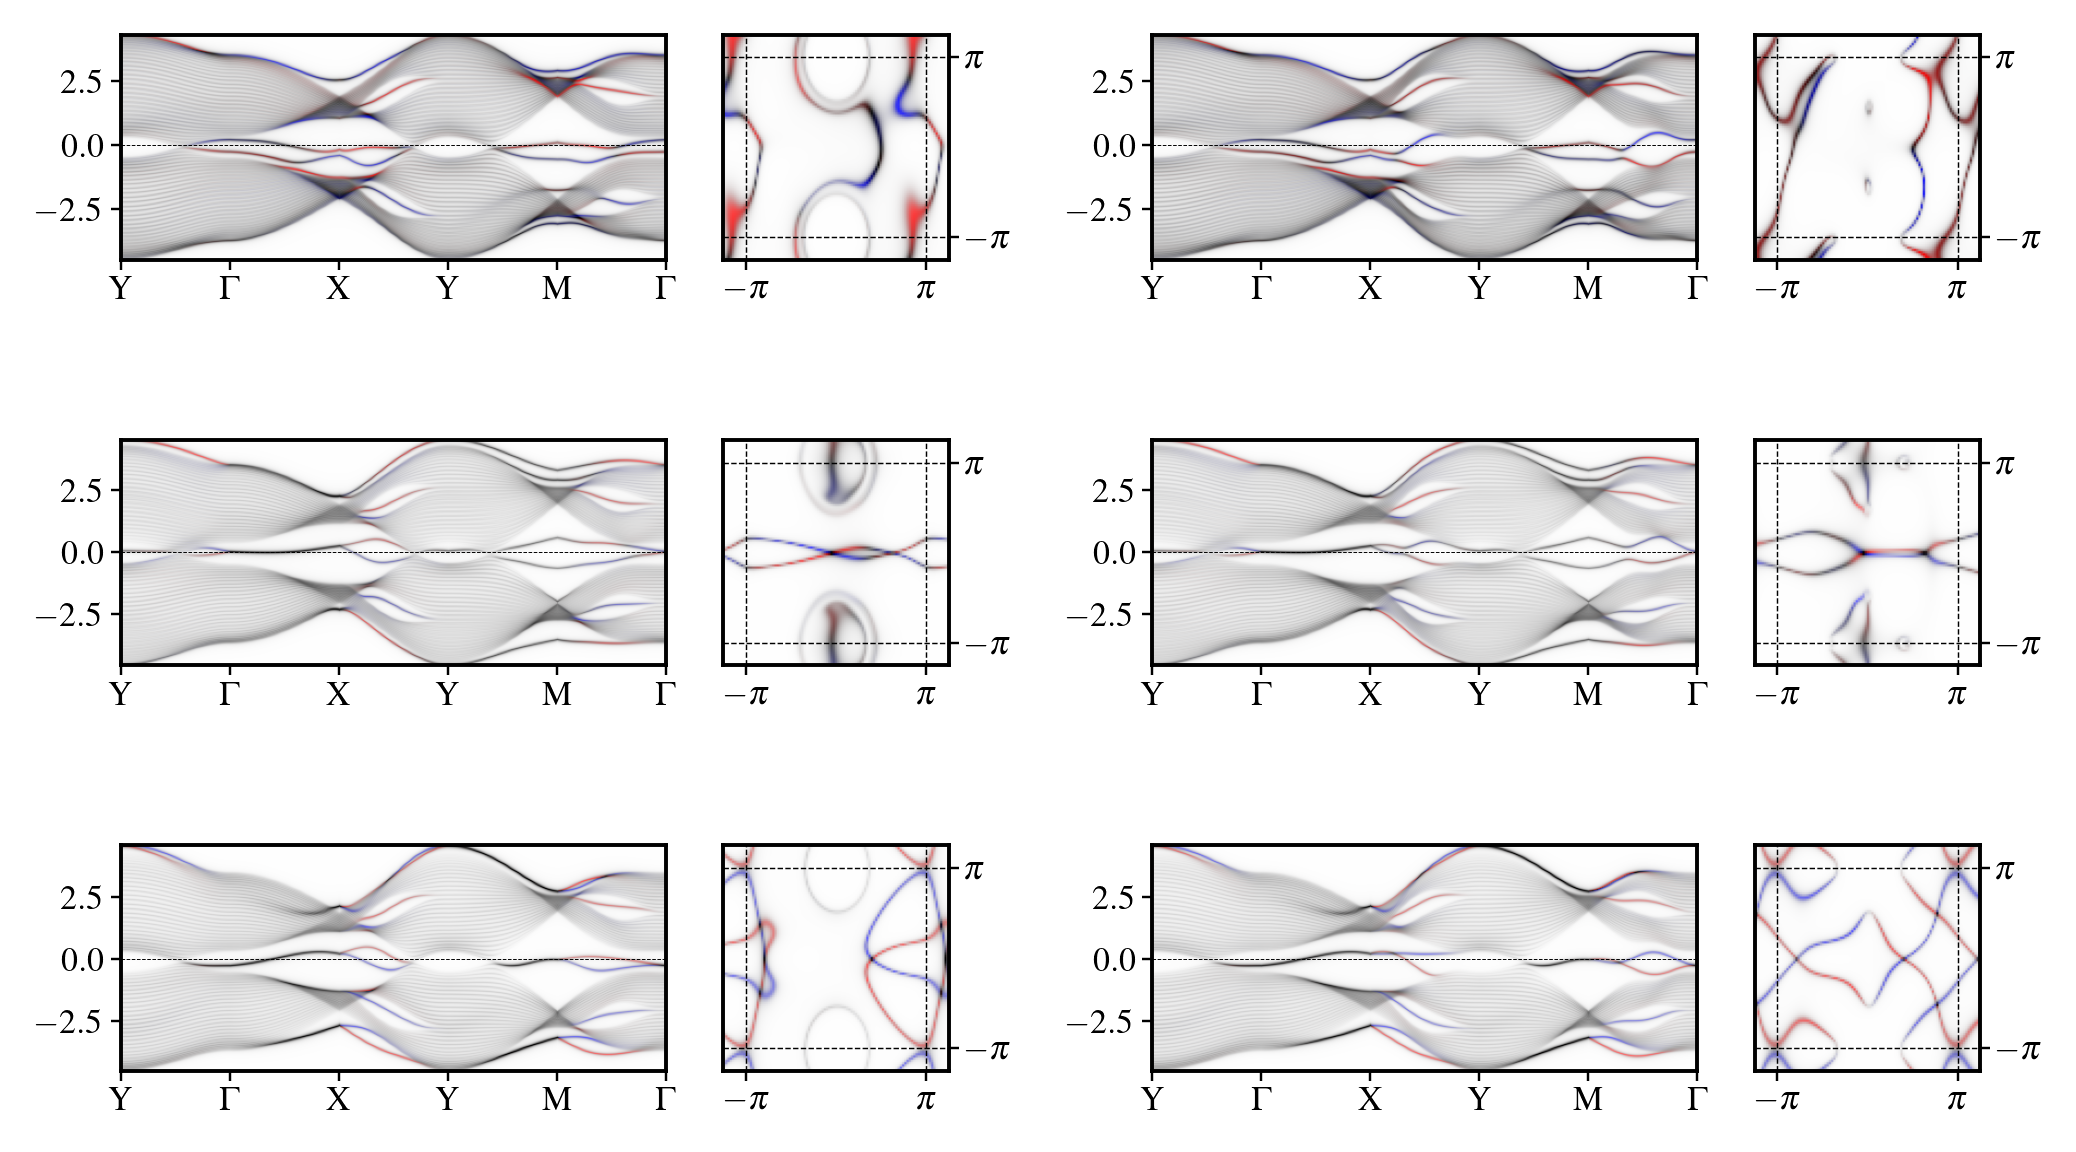

In [89]:
from matplotlib.gridspec import GridSpec

height_ratios = [1, 1, 1]
width_ratios = [1, 1, 1, 0.4, 1, 1, 1]
ratio = len(height_ratios) / len(width_ratios)

fig = plt.figure(figsize=(aps_figwidth, aps_figwidth * 1.3 * ratio), dpi=350)
gs = GridSpec(
    3, 7, figure=fig, height_ratios=height_ratios, width_ratios=width_ratios, hspace=0.8
)


drum_boundary_path_ax = [fig.add_subplot(gs[i, 0:2]) for i in range(3)]
drum_boundary_grid_ax = [fig.add_subplot(gs[i, 2]) for i in range(3)]
weyl_boundary_path_ax = [fig.add_subplot(gs[i, 4:6]) for i in range(3)]
weyl_boundary_grid_ax = [fig.add_subplot(gs[i, 6]) for i in range(3)]

for i in range(3):

    ################### boundary path ###################
    # drumhead
    spec_walk = spec_walks["spec_boundary_path"][i, 0]
    drum_boundary_path_ax[i].imshow(
        spec_walk,
        extent=(
            0,
            len(spec_walks["paths"][0]),
            spec_walks["spec_e_vals"][i, 0][0],
            spec_walks["spec_e_vals"][i, 0][-1],
        ),
        aspect="auto",
        origin="lower",
    )
    drum_boundary_path_ax[i].set_xticks(
        spec_walks["path_positions"][0], spec_walks["path_labels"][0]
    )

    # weyl
    spec_walk = spec_walks["spec_boundary_path"][i, 1]
    weyl_boundary_path_ax[i].imshow(
        spec_walk,
        extent=(
            0,
            len(spec_walks["paths"][0]),
            spec_walks["spec_e_vals"][i, 1][0],
            spec_walks["spec_e_vals"][i, 1][-1],
        ),
        aspect="auto",
        origin="lower",
    )
    weyl_boundary_path_ax[i].set_xticks(
        spec_walks["path_positions"][0], spec_walks["path_labels"][0]
    )

    ################### boundary grid ###################
    # drumhead
    spec_grid = spec_grids["spec_boundary_grid"][i, 0]

    drum_boundary_grid_ax[i].imshow(
        np.swapaxes(spec_grid, 0, 1),
        extent=(
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
        ),
    )

    drum_boundary_grid_ax[i].set_xticks([-np.pi, np.pi])
    drum_boundary_grid_ax[i].set_yticks([-np.pi, np.pi])
    drum_boundary_grid_ax[i].set_yticklabels(["$-\\pi$", "$\\pi$"])
    drum_boundary_grid_ax[i].set_xticklabels(["$-\\pi$", "$\\pi$"])

    # weyl
    spec_grid = spec_grids["spec_boundary_grid"][i, 1]

    weyl_boundary_grid_ax[i].imshow(
        np.swapaxes(spec_grid, 0, 1),
        extent=(
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
            -np.pi * (1 + spillover),
            np.pi * (1 + spillover),
        ),
    )

    weyl_boundary_grid_ax[i].set_xticks([-np.pi, np.pi])
    weyl_boundary_grid_ax[i].set_yticks([-np.pi, np.pi])
    weyl_boundary_grid_ax[i].set_yticklabels(["$-\\pi$", "$\\pi$"])
    weyl_boundary_grid_ax[i].set_xticklabels(["$-\\pi$", "$\\pi$"])

for j in range(3):
    for a in (weyl_boundary_grid_ax[j], drum_boundary_grid_ax[j]):
        a.tick_params(length=2, width=0.5, pad=1.3)
        a.axhline(-np.pi, color="k", ls="--", lw=0.3)
        a.axhline(np.pi, color="k", ls="--", lw=0.3)
        a.axvline(-np.pi, color="k", ls="--", lw=0.3)
        a.axvline(np.pi, color="k", ls="--", lw=0.3)

        a.tick_params(
            left=False,
            labelleft=False,
            right=True,
            labelright=True,
        )
        # if j < 2:
        #     a.tick_params(
        #         bottom=False,
        #         labelbottom=False,
        #     )

    for a in (drum_boundary_path_ax[j], weyl_boundary_path_ax[j]):
        a.axhline(0, color="k", ls="--", lw=0.2)
        a.tick_params(length=2, width=0.5, pad=1.3)
        # if j < 2:
        #     a.tick_params(
        #         bottom=False,
        #         labelbottom=False,
        #     )
plt.tight_layout()
# plt.savefig("perturbation.png")